# 2. ETL tabla 'card'

Partiendo de la conexión de Python con la página web de Kaggle a través de la librería 'kagglehub', hemos descargado el archivo 'cards_data.csv' del conjunto de datos llamado 'Financial Transactions Dataset: Analytics'. Procederemos a limpiarlo, transformarlo, y le haremos un análisis exploratorio.

### Librerías importadas

In [1]:
import kagglehub
import numpy as np
import pandas as pd
from datetime import datetime
import os
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as stat
from dotenv import load_dotenv

### Constantes

* Directorio actual del script de Python

In [3]:
# Consultar el directorio actual de trabajo y guardar en la constante 'CURRENT_DIRECTORY'
CURRENT_DIRECTORY=os.getcwd()
CURRENT_DIRECTORY

'C:\\Users\\germa\\Documents\\Python\\edicion_12.0\\Proyecto_integrador\\ETL_finales'

* Directorio de la carpeta 'files'

In [4]:
# Crear una carpeta llamada 'files' dentro del directorio actual de trabajo
new_folder = 'files'

FILES_DIRECTORY=os.path.join(CURRENT_DIRECTORY, new_folder)

try:
    os.makedirs(FILES_DIRECTORY, exist_ok=True)
    print(f"Carpeta creada en: {FILES_DIRECTORY}")

except OSError as e:
    print(f"Error al crear la carpeta: {e}")

Carpeta creada en: C:\Users\germa\Documents\Python\edicion_12.0\Proyecto_integrador\ETL_finales\files


### Descarga del archivo de datos crudos

In [5]:
# Descargar el archivo de datos crudos 'cards_data.csv' del dataset 'Financial Transactions Dataset: Analytics' de la página
# web de Kaggle
path = kagglehub.dataset_download('computingvictor/transactions-fraud-datasets', path='cards_data.csv')
print('Archivo csv descargado en:', path)

Archivo csv descargado en: C:\Users\germa\.cache\kagglehub\datasets\computingvictor\transactions-fraud-datasets\versions\1\cards_data.csv


In [6]:
# Convertir el archivo descargado en forma de dataframe
card_data = pd.read_csv(path)

In [7]:
# Revisar el dataframe
card_data

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No
3,42,825,Visa,Credit,4879494103069057,08/2024,693,NO,1,$12400,01/2003,2012,No
4,4659,825,Mastercard,Debit (Prepaid),5722874738736011,03/2009,75,YES,1,$28,09/2008,2009,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,Amex,Credit,300609782832003,01/2024,663,YES,1,$6900,11/2000,2013,No
6142,2711,185,Visa,Credit,4718517475996018,01/2021,492,YES,2,$5700,04/2012,2012,No
6143,1305,1007,Mastercard,Credit,5929512204765914,08/2020,237,NO,2,$9200,02/2012,2012,No
6144,743,1110,Mastercard,Debit,5589768928167462,01/2020,630,YES,1,$28074,01/2020,2020,No


### Información general del dataframe

In [8]:
# Mostrar las primeras 3 filas del dataframe para ver su contenido
card_data.sample(3)

,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
1583,532,1239,Mastercard,Credit,5539431041002735,09/2024,932,YES,2,$11100,01/2020,2020,No
2379,3546,1513,Mastercard,Credit,5257923747690161,11/2020,547,YES,2,$8900,06/2012,2012,No
3239,5183,125,Amex,Credit,398638761436555,01/2021,177,YES,2,$6400,10/2010,2011,No


El dataframe contiene datos de las tarjetas (un registro equivale a una tarjeta):
* **id**: Es el código identificador de la tarjeta.
* **client_id**: Es el código identificador del cliente que es el titular de la tarjeta.
* **card_brand**: Es la marca de la red de pago a la que pertenece la tarjeta (Visa, Mastercard, Amex y Discover).
* **card_type**: Es el tipo de tarjeta (Debit, Credit, Debit (Prepaid)).
* **card_number**: Es el número principal de tarjeta (contienen 15 o 16 dígitos dependiendo de la marca).
* **expires**: Es el mes y el año de expiración de la tarjeta.
* **cvv**: Es el código de seguridad de la tarjeta (contienen 3 o 4 dígitos dependiendo de la marca).
* **has_chip**: Indica si la tarjeta cuenta o no con chip (YES, NO).
* **num_cards_issued**:	Es el número total de tarjetas (plásticos) que se han emitido o generado asociados a una tarjeta, ya sea por pérdida, robo, caducidad, o deterioro.
* **credit_limit**: El límite de una tarjeta de crédito es el monto máximo en dólares que una entidad financiera te permite gastar o financiar en compras (en un pago o en cuotas) y adelantos en efectivo. Este tope disminuye con cada uso y se libera al pagar el resumen. El límite de una tarjeta de débito está dado por el saldo disponible en dólares en la cuenta bancaria.
* **acct_open_date**: Es el mes y el año de apertura/activación de la tarjeta.
* **year_pin_last_changed**: Es el año en que la tarjeta recibió el último cambio de PIN. El PIN (Personal Identification Number) es un código numérico de seguridad, generalmente de 4 dígitos, que actúa como contraseña personal para autorizar transacciones con tarjetas de débito o crédito.
* **card_on_dark_web**: Indica si la tarjeta se encuentra o no en la dark web, es decir, se refiere a que los datos asociados a la tarjeta han sido o no robados y si están siendo o no comercializados en el mercado negro de internet (Yes, No).

In [9]:
# Explorar la información general del dataframe
card_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   id                     6146 non-null   int64 
 1   client_id              6146 non-null   int64 
 2   card_brand             6146 non-null   object
 3   card_type              6146 non-null   object
 4   card_number            6146 non-null   int64 
 5   expires                6146 non-null   object
 6   cvv                    6146 non-null   int64 
 7   has_chip               6146 non-null   object
 8   num_cards_issued       6146 non-null   int64 
 9   credit_limit           6146 non-null   object
 10  acct_open_date         6146 non-null   object
 11  year_pin_last_changed  6146 non-null   int64 
 12  card_on_dark_web       6146 non-null   object
dtypes: int64(6), object(7)
memory usage: 624.3+ KB


Observamos lo siguiente:

* El dataframe contiene 6.416 registros, y 13 columnas.
* No existen valores nulos.
* Columnas con tipo de dato 'int': 'id' ,' client_id' , 'card_number',' cvv', 'num_cards_issued', 'year_pin_last_changed'.
* Columnas con tipo de dato 'str': 'card_brand','card_type','expires','has_chip','credit_limit','acct_open_date', 'card_on_dark_web'.

Antes de comenzar con la limpieza y transformación de datos, haremos una copia del dataframe original, y trabajaremos sobre la copia. De esta forma conservamos los datos originales por si en algún momento necesitamos consultarlos.

In [10]:
card = card_data.copy()

## Limpieza y transformación de datos

### id

* Objetivo:

Explorar si los valores se repiten, y renombrar la columna.

In [11]:
# Explorar los datos únicos
card.id.unique()

array([4524, 2731, 3701, ..., 1305,  743, 3199], shape=(6146,))

In [12]:
# Confirmar la longitud de datos de la columna
len(card.id.unique())

6146

* id_card: Contiene 6.146 registros únicos.

In [13]:
# Cambiar de nombre la columna
card.rename(columns={'id':'id_card'}, inplace=True)

### client_id

* Se conserva la columna tal cual se encuentra.

### card_brand

Objetivos:

* Identificar los tipos de marca de tarjeta
* Conocer el porcentaje de uso de cada marca
* Agregar una tabla dimensional

In [14]:
# Conocer los datos únicos que existen en la columna card_brand
card.card_brand.unique()

array(['Visa', 'Mastercard', 'Discover', 'Amex'], dtype=object)

In [15]:
# Contar las veces que se repite cada dato en la columna card_brand
card.card_brand.value_counts()

card_brand
Mastercard    3209
Visa          2326
Amex           402
Discover       209
Name: count, dtype: int64

In [16]:
# Conocer el porcentaje de repetición de cada valor en la comuna card_brand
(card['card_brand'].value_counts(normalize=True) * 100).round(2)

card_brand
Mastercard    52.21
Visa          37.85
Amex           6.54
Discover       3.40
Name: proportion, dtype: float64

* card_brand: Mastercard representa el 52.21%, seguido de Visa con 37.85%.

In [17]:
# Crear una nueva columna llamada 'card_brand_id' para codificar con valores numéricos que empiezan en 1 las marcas de tarjetas en orden ascendente
card['card_brand_id'] = pd.factorize(card['card_brand'] , sort=True)[0] + 1
card.sample(5)

,id_card,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id
821,483,1650,Mastercard,Credit,5656952388282689,07/2021,589,YES,2,$10200,01/2020,2020,No,3
5844,1990,1375,Visa,Credit,4750738672953674,03/2022,97,YES,1,$19800,02/2020,2020,No,4
4769,1374,1841,Mastercard,Debit,5987109951536861,04/2019,424,YES,2,$17386,02/2017,2017,No,3
5438,1100,90,Visa,Debit,4224384711964351,03/2015,585,YES,2,$26872,02/2006,2015,No,4
3794,3911,275,Visa,Credit,4348372675855427,05/2023,727,YES,2,$6200,07/2009,2010,No,4


In [18]:
# Crear una nueva tabla llamada 'card_brand' a partir de la tabla 'card', para separar en el modelo de datos las 'card_brand'
# de las 'card', asegurar que no existan duplicados, y ordenar la tabla por la columna 'card_brand_id'
card_brand = (card[['card_brand_id', 'card_brand']].drop_duplicates().sort_values('card_brand_id'))
card_brand

,card_brand_id,card_brand
73,1,Amex
42,2,Discover
4,3,Mastercard
0,4,Visa


In [19]:
# Resetear el índice de la nueva tabla
card_brand = card_brand.reset_index(drop=True)
card_brand

,card_brand_id,card_brand
0,1,Amex
1,2,Discover
2,3,Mastercard
3,4,Visa


In [20]:
# Renombrar el nombre de la columna 'card_brand_id' para que la nomenclatura del id esté alineada a las primary key
card_brand.rename(columns={'card_brand_id': 'id_card_brand'}, inplace=True)
card_brand

,id_card_brand,card_brand
0,1,Amex
1,2,Discover
2,3,Mastercard
3,4,Visa


In [21]:
# Eliminar columna 'card_brand' de la tabla 'card'
card.drop('card_brand', axis=1, inplace=True)
card.sample(5)

,id_card,client_id,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id
706,5049,1512,Debit,5008189212339000,09/2019,644,YES,2,$26357,10/2006,2013,No,3
3931,5570,557,Debit,5755010791716629,04/2022,497,YES,2,$6090,11/2009,2011,No,3
1446,2716,561,Debit (Prepaid),5918296616309874,05/2024,983,YES,1,$69,04/2013,2013,No,3
4692,5243,1458,Debit,5016909247780196,06/2020,479,NO,2,$11094,10/2011,2011,No,3
4030,3686,383,Credit,329374832925921,05/2024,926,YES,1,$8200,07/2003,2012,No,1


### card_type

Objetivos:

* Identificar los tipos de tarjeta que existen
* Realizar cambio de formatos
* Conocer el porcentaje de uso
* Realizar tabla de dimensiones

In [22]:
# Conocer los valores únicos de la columna card_type
card.card_type.unique()

array(['Debit', 'Credit', 'Debit (Prepaid)'], dtype=object)

In [23]:
# Cambiar los nombres de las columnas
card['card_type'] = card['card_type'].replace({'Debit':'debit','Credit':'credit','Debit (Prepaid)':'debit_prepaid'})

In [24]:
# Contar las veces que se repite cada dato en la columna card_type
card.card_type.value_counts()

card_type
debit            3511
credit           2057
debit_prepaid     578
Name: count, dtype: int64

In [25]:
# Conocer el porcentaje de cada dato en la columna card_type
(card['card_type'].value_counts(normalize=True) * 100).round(2)

card_type
debit            57.13
credit           33.47
debit_prepaid     9.40
Name: proportion, dtype: float64

* card_type: Existen más tarjetas emitidas de débito (57.13%) que de crédito (33.47%).

In [26]:
# Crear una nueva columna llamada 'card_type_id' para codificar con valores numéricos que empiezan en 1 los tipos de tarjetas en orden ascendente
card['card_type_id'] = pd.factorize(card['card_type'] , sort=True)[0] + 1
card.sample(5)

,id_card,client_id,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
3358,4189,343,credit,4742225389926537,08/2024,690,YES,1,$11000,08/2006,2017,No,4,1
528,5730,1950,debit,5931155323451029,05/2024,580,YES,2,$10841,11/2017,2017,No,3,2
1222,1399,1724,credit,329884815703027,05/2022,818,YES,2,$7400,02/2020,2020,No,1,1
2608,3549,949,credit,5272390505326909,06/2022,137,YES,2,$8000,06/2012,2012,No,3,1
5070,5027,1331,debit_prepaid,5376013028883652,09/2021,68,YES,1,$26,10/2005,2010,No,3,3


In [27]:
# Crear una nueva tabla llamada 'card_type' a partir de la tabla 'card', para separar en el modelo de datos los 'card_type'
# de las 'card', asegurar que no existan duplicados, y ordenar la tabla por la columna 'card_type_id'
card_type = (card[['card_type_id','card_type']].drop_duplicates().sort_values('card_type_id'))
card_type

,card_type_id,card_type
3,1,credit
0,2,debit
4,3,debit_prepaid


In [28]:
# Resetar el ínndice de la nueva tabla
card_type = card_type.reset_index(drop=True)
card_type

,card_type_id,card_type
0,1,credit
1,2,debit
2,3,debit_prepaid


In [29]:
# Cambiar el nombre de la columna 'card_type_id' para que la nomenclatura del id esté alineada a las primary key
card_type.rename(columns={'card_type_id': 'id_card_type'}, inplace=True)
card_type

,id_card_type,card_type
0,1,credit
1,2,debit
2,3,debit_prepaid


In [30]:
# Eliminar columna 'card_type' de la tabla 'card'
card.drop('card_type', axis=1, inplace=True)
card.sample(5)

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
259,4112,1783,323782494048404,03/2020,659,YES,1,$9800,08/2003,2010,No,1,1
3591,1223,649,5155724078477847,06/2024,606,YES,2,$11401,02/2010,2016,No,3,2
2166,5753,1445,6800970747167326,04/2022,163,YES,2,$10200,12/1997,2011,No,2,1
4683,411,531,334781877942824,09/2023,660,YES,1,$6700,01/2020,2020,No,1,1
675,5518,719,5866359917107313,12/2023,102,YES,1,$21727,11/2008,2008,No,3,2


### card_number

Objetivos:

* Revisar que los números de tarjetas tengan el número de caracteres 15 o 16 de acuerdo a la normativa
* Verificar el número de tarjetas promedio que utiliza cada cliente

In [31]:
# Verificar el número de datos únicos dentro de la columna
card.card_number.unique()

array([4344676511950444, 4956965974959986, 4582313478255491, ...,
       5929512204765914, 5589768928167462, 4994011318343994],
      shape=(6146,))

In [32]:
# Cambiar el tipo de dato a str para corroborar la longitud de cada registro
card['card_number'] = card['card_number'].astype(str)

In [33]:
# Verificar que todos los registros dentro de la columna contengan 15 o 16 dígitos
card['valid_length'] = card['card_number'].str.len().isin([15, 16])

In [34]:
card['valid_length'].value_counts()

valid_length
True    6146
Name: count, dtype: int64

In [35]:
# Eliminar columna 'valid_length' de la tabla 'card'
card.drop('valid_length', axis=1, inplace=True)
card.sample(5)

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
3065,5473,1615,4003165279623450,03/2023,317,YES,1,$15535,11/2006,2015,No,4,2
3369,4542,1196,4898915603819946,06/2020,656,YES,1,$11100,09/2003,2011,No,4,1
2886,131,1195,5516369728570927,10/2022,822,YES,1,$10369,01/2007,2011,No,3,2
5660,1326,624,5620777347987312,04/2019,203,YES,1,$12931,02/2013,2013,No,3,2
436,1783,1990,4862011857697370,05/2022,405,YES,1,$9600,02/2020,2020,No,4,1


In [36]:
# Agrupar la columna 'card_number' por el id de cliente para poder obtener el promedio de tarjetas que usa cada cliente
cards_per_client = (card.groupby('client_id')['card_number'].nunique())

In [37]:
# Promedio de tarjetas por cliente
cards_per_client.describe().round(2)

count    2000.00
mean        3.07
std         1.64
min         1.00
25%         2.00
50%         3.00
75%         4.00
max         9.00
Name: card_number, dtype: float64

In [38]:
# Lista de los 10 clientes con más tarjetas
cards_per_client.sort_values(ascending=False).head(10)

client_id
797     9
1741    9
1301    9
921     8
665     8
1031    8
27      8
1416    8
1811    8
1512    8
Name: card_number, dtype: int64

* Se valida que ningún número de tarjeta se repite, y que todos los registros contienen 15 o 16 dígitos dependiendo de la marca de tarjeta
* Cada cliente tiene en promedio 3 tarjetas diferentes

In [39]:
# Confirmar que el cliente "1301" use 9 tarjetas diferentes como validación de código anterior
card[card['client_id'] == 1301]

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
335,3136,1301,4199613929770276,09/2023,765,YES,1,$22833,05/2013,2013,No,4,2
336,755,1301,4912898188628991,11/2022,446,YES,1,$48502,01/2020,2020,No,4,2
337,2787,1301,4729953228374508,07/2022,461,YES,2,$34888,04/2019,2019,No,4,2
338,4435,1301,4164595738782783,08/2019,90,NO,1,$29503,08/2014,2014,No,4,2
339,378,1301,5036328460113700,08/2021,627,YES,2,$19570,01/2019,2019,No,3,2
340,3189,1301,5975006425756630,12/2023,551,YES,1,$22297,05/2017,2017,No,3,2
341,3595,1301,4420959167134444,09/2023,75,YES,1,$20031,06/2015,2015,No,4,2
342,1481,1301,5016998590035219,02/2020,597,YES,2,$30323,02/2020,2020,No,3,2
343,390,1301,308100975355379,04/2024,881,YES,1,$19000,01/2020,2020,No,1,1


In [40]:
# Una vez analizada la columna, cambiar nuevamente el tipo de dato a int
card['card_number'] = card['card_number'].astype(int)

### expires

Objetivo:

* cambiar el tipo de dato de la columna a 'datetime'

In [41]:
card['expires'] = pd.to_datetime(card['expires'])

C:\Users\germa\AppData\Local\Temp\ipykernel_25480\3693923547.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  card['expires'] = pd.to_datetime(card['expires'])


In [42]:
# Chequear de tipo de dato 'datetime' de columna
card['expires'].dtypes

dtype('<M8[ns]')

In [43]:
# Ver cómo queda la columna
card['expires'].head(3)

0   2022-12-01
1   2020-12-01
2   2024-02-01
Name: expires, dtype: datetime64[ns]

### cvv

Objetivo: 

* verificar que todos los registros contengan 4 o menos dígitos de acuerdo a normativa

In [44]:
# Validar que los registros tengan 4 dígitos o menos
card['cvv_valid'] = card['cvv'].astype(str).str.len() <= 4

In [45]:
card['cvv_valid'].value_counts()

cvv_valid
True    6146
Name: count, dtype: int64

* cvv: Todos los registros contienen 4 dígitos o menos

In [46]:
# Eliminar validación
card.drop('cvv_valid', axis=1, inplace=True)

In [47]:
# Verificar columnas existentes
card.columns

Index(['id_card', 'client_id', 'card_number', 'expires', 'cvv', 'has_chip',
       'num_cards_issued', 'credit_limit', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web', 'card_brand_id',
       'card_type_id'],
      dtype='object')

### has_chip

Objetivo: 

* Cambiar a minúsculas el contenido de las columnas y calcular el porcentaje de tarjetas que contiene chip

In [48]:
# Identificar los valores unicos de la columna has_chip
card.has_chip.unique()

array(['YES', 'NO'], dtype=object)

In [49]:
# Cambiar el texto a minúsculas
card['has_chip'] = card['has_chip'].str.lower()

In [50]:
# Contar cuántas veces se repite cada valor único
card.has_chip.value_counts()

has_chip
yes    5500
no      646
Name: count, dtype: int64

In [51]:
# Conocer el porcentaje de las veces que se repite cada valor único
(card['has_chip'].value_counts(normalize=True)*100).round(2)

has_chip
yes    89.49
no     10.51
Name: proportion, dtype: float64

* El 89,49% de las tarjetas contiene chip.

### num_cards_issued

Objetivo:

* Verificar que al menos exista 1 tarjeta asociada por cada número de tarjeta

In [52]:
card[card['num_cards_issued'] < 1]

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id


In [53]:
(card['num_cards_issued'] >= 1).value_counts()

num_cards_issued
True    6146
Name: count, dtype: int64

* Se verifica que al menos exista 1 tarjeta asociada por cada número de tarjeta

### credit_limit

Objetivos:

* Agregar al título la palabra 'usd'
* retirar signo de $ a cada registro
* Convertir la columna a tipo de dato float
* Segmentar a los clientes en base a su límite de crédito y conocer el porcentaje

In [54]:
# Renombrar la columna
card.rename(columns={'credit_limit': 'credit_limit_usd'}, inplace=True)
card.columns

Index(['id_card', 'client_id', 'card_number', 'expires', 'cvv', 'has_chip',
       'num_cards_issued', 'credit_limit_usd', 'acct_open_date',
       'year_pin_last_changed', 'card_on_dark_web', 'card_brand_id',
       'card_type_id'],
      dtype='object')

In [55]:
# Eliminar el signo "$" de los registros
card['credit_limit_usd'] = (card['credit_limit_usd'].str.replace('$', '', regex=False))
card.sample(5)

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
3236,2802,92,5123318890212912,2013-10-01,821,yes,1,25670,05/1999,2010,No,3,2
349,344,1775,5309940542589432,2020-02-01,924,yes,2,17201,01/2015,2015,No,3,2
735,3704,171,4992498548379230,2015-10-01,867,yes,2,13116,07/2003,2012,No,4,2
4297,2414,810,310875942602694,2009-09-01,236,yes,2,10800,04/2001,2011,No,1,1
1972,226,729,5279503639469023,2020-02-01,613,yes,2,23039,01/2010,2010,No,3,2


In [56]:
# Cambiar a tipo de dato 'float'
card['credit_limit_usd'] = card['credit_limit_usd'].astype('float')

In [57]:
# Revisar si existen datos nulos
card['credit_limit_usd'].isna().sum()

np.int64(0)

In [58]:
# Revisar estadistica general de la columna 'credit_limit'
card['credit_limit_usd'].describe().round(2)

count      6146.00
mean      14347.49
std       12014.46
min           0.00
25%        7042.75
50%       12592.50
75%       19156.50
max      151223.00
Name: credit_limit_usd, dtype: float64

In [59]:
# Crear una copia del dataframe 'card' para incluir una columna llamada 'credit_segment' que va a servir para realizar el análisis exploratorio
card_eda = card.copy()
card_eda. sample(5)

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
3655,862,450,4417073426918706,2024-12-01,403,yes,2,23687.0,01/2020,2020,No,4,2
4798,5637,656,4105075889994254,2024-06-01,789,yes,2,25639.0,11/2010,2010,No,4,2
491,3543,1684,5287533090911331,2014-04-01,946,yes,1,13756.0,06/2012,2012,No,3,2
1352,1545,1833,5390138872145738,2020-03-01,267,yes,1,98.0,02/2020,2020,No,3,3
2756,1160,1926,4833362009066626,2023-09-01,611,no,2,793.0,02/2008,2008,No,4,2


In [60]:
# Segmentar el límite de crédito en dólares, se usa -0.01 para lograr integrar a los 0 a los bins y que no arroje error
# Esta segmentación se realizó en base al análisis exploratorio que se encuentra en el siguiente apartado. Se decidió segmentar así:
"""
low <= usd 10.000
medium > usd 10.000 y <= usd 20.000
high > usd 20.000 y <= usd 40.000
premium > usd 40.000 y <= usd 80.000
ultra > usd 80.000
"""
card_eda['credit_segment'] = pd.cut(
    card_eda['credit_limit_usd'],
    bins=[-0.01, 10000, 20000, 40000, 80000, float('inf')],
    labels=['low', 'medium', 'high', 'premium', 'ultra']
)

In [61]:
# Contar los valores correspondientes a cada segmento de credito
card_eda['credit_segment'].value_counts()

credit_segment
medium     2385
low        2348
high       1233
premium     162
ultra        18
Name: count, dtype: int64

In [62]:
# Revisar el porcentaje correspondiente a cada segmento
card_eda['credit_segment'].value_counts(normalize=True).round(4) * 100

credit_segment
medium     38.81
low        38.20
high       20.06
premium     2.64
ultra       0.29
Name: proportion, dtype: float64

* Se realizó una segmentación del límite de crédito observando que arriba del 70% tiene un crédito bajo y medio (<= 20,000 usd), con algunos outliers en la categoría ultra, confirmado con gráfico en la siguiente sección.

### acct_open_date

Objetivo:

* cambiar el tipo de dato de la columna a 'datetime'

In [63]:
card['acct_open_date'] = pd.to_datetime(card['acct_open_date'])

C:\Users\germa\AppData\Local\Temp\ipykernel_25480\2652254099.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  card['acct_open_date'] = pd.to_datetime(card['acct_open_date'])


In [64]:
# Chequear de tipo de dato 'datetime' de columna
card['acct_open_date'].dtypes

dtype('<M8[ns]')

In [65]:
# Ver cómo queda la columna
card['acct_open_date'].head(3)

0   2002-09-01
1   2014-04-01
2   2003-07-01
Name: acct_open_date, dtype: datetime64[ns]

### year_pin_last_changed

* Se conserva la columna tal cual se encuentra.

### card_on_dark_web

Objetivo: 

* Identificar las tarjetas se han usado en la dark web
* Cambiar el texto a minúsculas

In [66]:
# Revisar los valores unicos
card.card_on_dark_web.unique()

array(['No'], dtype=object)

* Ninguna tarjeta fue utilizada en la dark web

In [67]:
# Cambiar el texto a minúsculas
card['card_on_dark_web'] = card['card_on_dark_web'].str.lower()
card.sample(5)

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
566,4597,705,5619919350397758,2021-10-01,786,yes,2,23.0,2006-09-01,2010,no,3,3
3757,5431,735,5436863739232627,2023-09-01,303,yes,1,34075.0,2005-11-01,2008,no,3,2
4835,5273,1228,5898436387057618,2022-10-01,793,yes,1,17832.0,2013-10-01,2013,no,3,2
950,3116,577,5591077047400631,2020-09-01,615,yes,1,17936.0,2012-05-01,2012,no,3,2
695,1795,1804,4970053603571619,2022-04-01,864,yes,2,2174.0,2020-02-01,2020,no,4,2


## Análisis Exploratorio de Datos (EDA)

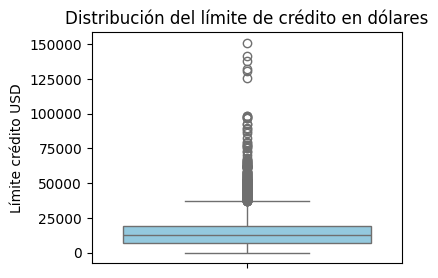

In [92]:
# Entender la distribución de credit_limit_usd y los outliers
plt.figure(figsize=(4, 3))
sns.boxplot(y=card['credit_limit_usd'], color='skyblue', orient='v')
plt.title('Distribución del límite de crédito en dólares')
plt.ylabel('Límite crédito USD')
plt.show()

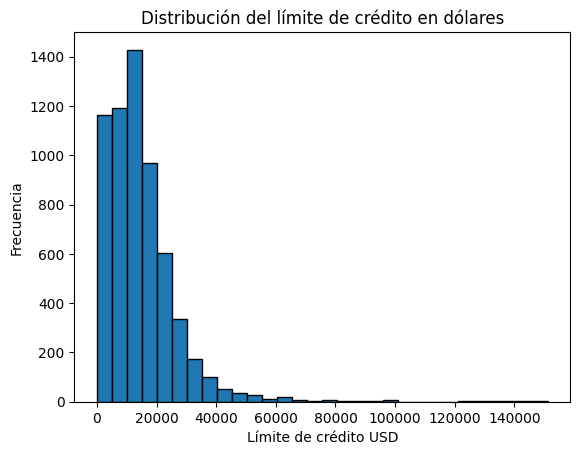

In [93]:
# Creación de otro gráfico para confirmar la frecuencia de distribución de límite de crédito
plt.hist(card['credit_limit_usd'], bins=30, edgecolor='black')
plt.title('Distribución del límite de crédito en dólares')
plt.xlabel('Límite de crédito USD')
plt.ylabel('Frecuencia')
plt.show()

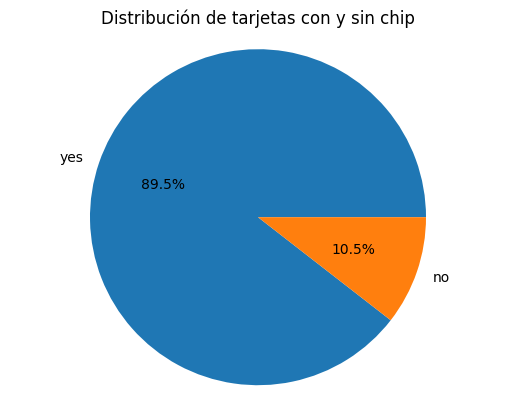

In [94]:
has_chip_counts = card['has_chip'].value_counts()

plt.pie(
    has_chip_counts,
    labels=has_chip_counts.index,
    autopct='%1.1f%%'
)

plt.title('Distribución de tarjetas con y sin chip')
plt.axis('equal')
plt.show()

In [95]:
credit_by_brand = (
    card.groupby('card_brand_id')['credit_limit_usd']
    .mean()
    .reset_index()
)

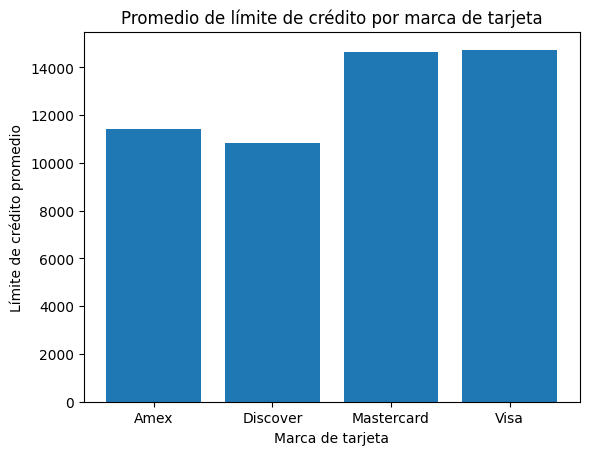

In [96]:
plt.bar(
    credit_by_brand['card_brand_id'],
    credit_by_brand['credit_limit_usd']
)

plt.xticks(credit_by_brand['card_brand_id'])

plt.title('Promedio de límite de crédito por marca de tarjeta')
plt.xlabel('Marca de tarjeta')
plt.xticks(ticks=[1, 2,3,4], labels=['Amex', 'Discover', 'Mastercard', 'Visa'])
plt.ylabel('Límite de crédito promedio')

plt.show()

* Mastercard y Visa son las marcas de tarjetas que tienen mayor límite de crédito, rondando usd  14.000

In [97]:
credit_by_type = (
    card.groupby('card_type_id')['credit_limit_usd']
    .mean()
    .reset_index()
)

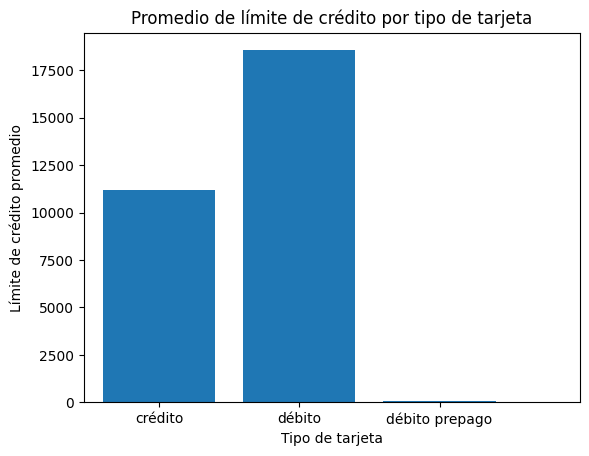

In [98]:
plt.bar(
    credit_by_type['card_type_id'],
    credit_by_type['credit_limit_usd']
)

plt.xticks(credit_by_brand['card_brand_id'])

plt.title('Promedio de límite de crédito por tipo de tarjeta')
plt.xlabel('Tipo de tarjeta')
plt.xticks(ticks=[1, 2, 3], labels=['crédito', 'débito', 'débito prepago'])
plt.ylabel('Límite de crédito promedio')

plt.show()

* Las tarjetas de débito son las que tienen un límite más alto. El límite de una tarjeta de débito está dado por el saldo disponible en dólares en la cuenta bancaria. En cambio, el límite de una tarjeta de crédito es el monto máximo en dólares que una entidad financiera permite gastar o financiar en compras (en un pago o en cuotas) y adelantos en efectivo.

## Tablas limpias a conectar con MySQL Workbench y a exportar a formato .csv

* Exploramos la información general de los dataframes a conectar con MySQL Workbench y a exportar en formato .csv

In [99]:
dataframe_list = [card, card_brand, card_type]
dataframe_name = ['card','card_brand','card_type']

for i, df in enumerate(dataframe_list):
    print('\n', f'dataframe ** {dataframe_name[i]} **:')
    print(df.info(show_counts=True), '\n')


 dataframe ** card **:
<class 'pandas.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_card                6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_number            6146 non-null   int64         
 3   expires                6146 non-null   datetime64[us]
 4   cvv                    6146 non-null   int64         
 5   has_chip               6146 non-null   str           
 6   num_cards_issued       6146 non-null   int64         
 7   credit_limit_usd       6146 non-null   float64       
 8   acct_open_date         6146 non-null   datetime64[us]
 9   year_pin_last_changed  6146 non-null   int64         
 10  card_on_dark_web       6146 non-null   str           
 11  card_brand_id          6146 non-null   int64         
 12  card_type_id           6146 non-null   int64     

* Cambiamos el directorio de trabajo a 'FILES_DIRECTORY' porque allí exportaremos las tablas 'limpias' en formato .csv

In [68]:
os.chdir(FILES_DIRECTORY)

* Chequeamos el directorio actual de trabajo

In [69]:
pwd!

'C:\\Users\\germa\\Documents\\Python\\edicion_12.0\\Proyecto_integrador\\ETL_finales\\files'

* Exportamos de las tablas 'limpias' a formato .csv

In [70]:
card.to_csv('card.csv', index=False)

In [102]:
card.to_csv('card.csv', index=False)
card_brand.to_csv('card_brand.csv', index=False)
card_type.to_csv('card_type.csv', index=False)

In [71]:
card

,id_card,client_id,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit_usd,acct_open_date,year_pin_last_changed,card_on_dark_web,card_brand_id,card_type_id
0,4524,825,4344676511950444,2022-12-01,623,yes,2,24295.0,2002-09-01,2008,no,4,2
1,2731,825,4956965974959986,2020-12-01,393,yes,2,21968.0,2014-04-01,2014,no,4,2
2,3701,825,4582313478255491,2024-02-01,719,yes,2,46414.0,2003-07-01,2004,no,4,2
3,42,825,4879494103069057,2024-08-01,693,no,1,12400.0,2003-01-01,2012,no,4,1
4,4659,825,5722874738736011,2009-03-01,75,yes,1,28.0,2008-09-01,2009,no,3,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6141,5361,185,300609782832003,2024-01-01,663,yes,1,6900.0,2000-11-01,2013,no,1,1
6142,2711,185,4718517475996018,2021-01-01,492,yes,2,5700.0,2012-04-01,2012,no,4,1
6143,1305,1007,5929512204765914,2020-08-01,237,no,2,9200.0,2012-02-01,2012,no,3,1
6144,743,1110,5589768928167462,2020-01-01,630,yes,1,28074.0,2020-01-01,2020,no,3,2


In [72]:
card.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   id_card                6146 non-null   int64         
 1   client_id              6146 non-null   int64         
 2   card_number            6146 non-null   int64         
 3   expires                6146 non-null   datetime64[ns]
 4   cvv                    6146 non-null   int64         
 5   has_chip               6146 non-null   object        
 6   num_cards_issued       6146 non-null   int64         
 7   credit_limit_usd       6146 non-null   float64       
 8   acct_open_date         6146 non-null   datetime64[ns]
 9   year_pin_last_changed  6146 non-null   int64         
 10  card_on_dark_web       6146 non-null   object        
 11  card_brand_id          6146 non-null   int64         
 12  card_type_id           6146 non-null   int64         
dtypes: 